### Read individual .csv files with predictions and store as one single .csv

In [355]:
import os
from pathlib import Path
import glob
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Base path: where to gather the outputs from
# csv output path: where to store the combined csv
base_path = "../results/csv/" 
subdir = "/bm_eq_nonoise"

csv_output_path = os.path.join(base_path, "combined")
csv_output_name = subdir + "_full.csv"

# Match filenames to only get the csv outputs
files = list(Path(base_path + subdir).rglob("*.csv"))

# Sort files by timechunk folder name (0 = station, 1 = timechunk)
files = sorted(files, key=lambda x:x.parents[1].name)

# Load into single df
df = pd.concat((pd.read_csv(file) for file in files), ignore_index=True)

# Keep only rows with predictions
pred_cols = ["p_probability", "s_probability"]
df = df[df[pred_cols].notna().any(axis=1)]

# Extract raw datetime string from time window directories
pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(pattern)

# Convert to datetime and insert into dataframe
df["start_dt"] = pd.to_datetime(matches["start_dt"], format="%Y%m%dT%H%M%SZ")
df["end_dt"] = pd.to_datetime(matches["end_dt"], format="%Y%m%dT%H%M%SZ")

# Sort df by window start time
df = df.sort_values(by="start_dt", ascending=True)

# Insert correct network code
# df["network"] = df["file_name"].str.extract(r'/(.*?)\.')
df["network"] = matches["network"].str.strip().str.upper()
df["station"] = matches["station"].str.strip().str.upper()

# Filter out rows with NaN for both p_probability and s_probability (no predicted picks)
df = df[df["p_probability"].notna() | df["s_probability"].notna()]

# Save dataframe to csv
os.makedirs(csv_output_path, exist_ok=True)
df.to_csv(csv_output_path + csv_output_name, index=False)

# Print some basic information about the number of predicted picks
num_rows = len(df)
num_files = len(files)
num_p_picks = sum(df["p_probability"].notna())
num_s_picks = sum(df["s_probability"].notna())
num_negatives = sum(df["p_probability"].isna() & df["s_probability"].isna())

print(f"Read {num_rows} predictions from {num_files} files.")
print(f"Number of p-arrivals: {num_p_picks}\nNumber of s-arrivals: {num_s_picks}\nTotal number of arrivals: {num_p_picks+num_s_picks}")
print(f"Number of empty predictions: {num_negatives}")

Read 2603 predictions from 2988 files.
Number of p-arrivals: 2603
Number of s-arrivals: 1627
Total number of arrivals: 4230
Number of empty predictions: 0


### Plot waveforms and predicted p/s picks

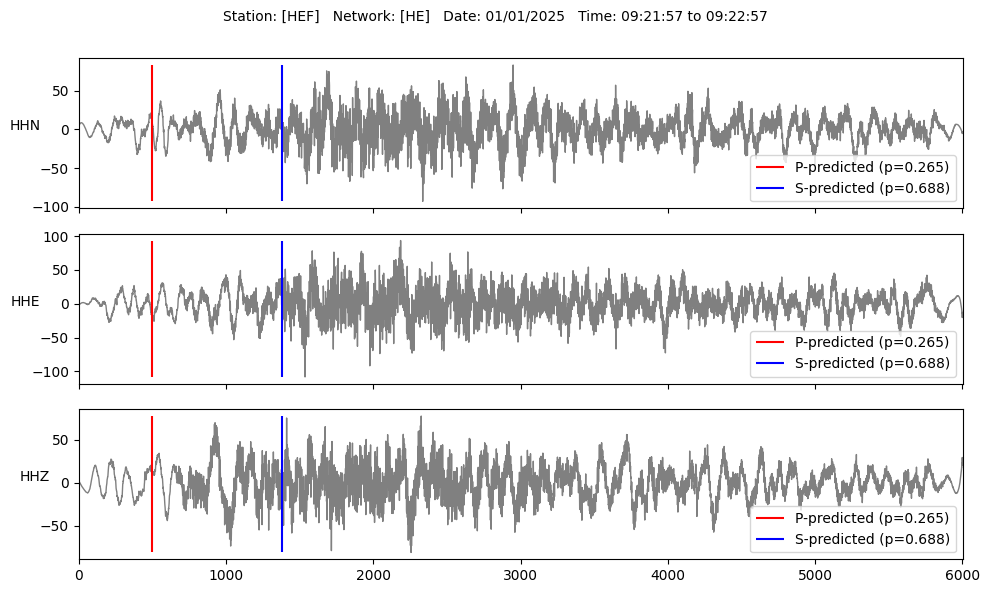

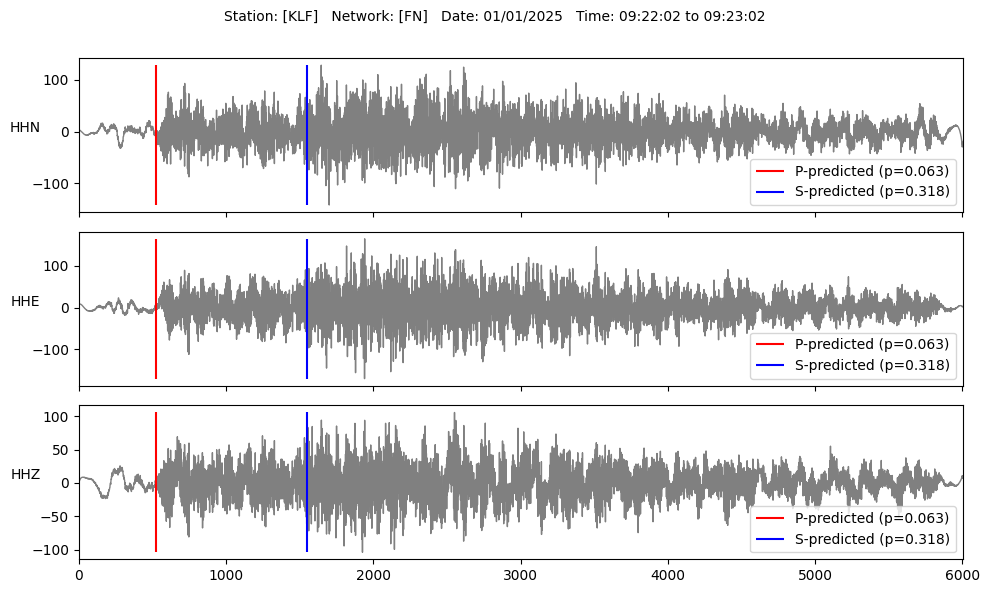

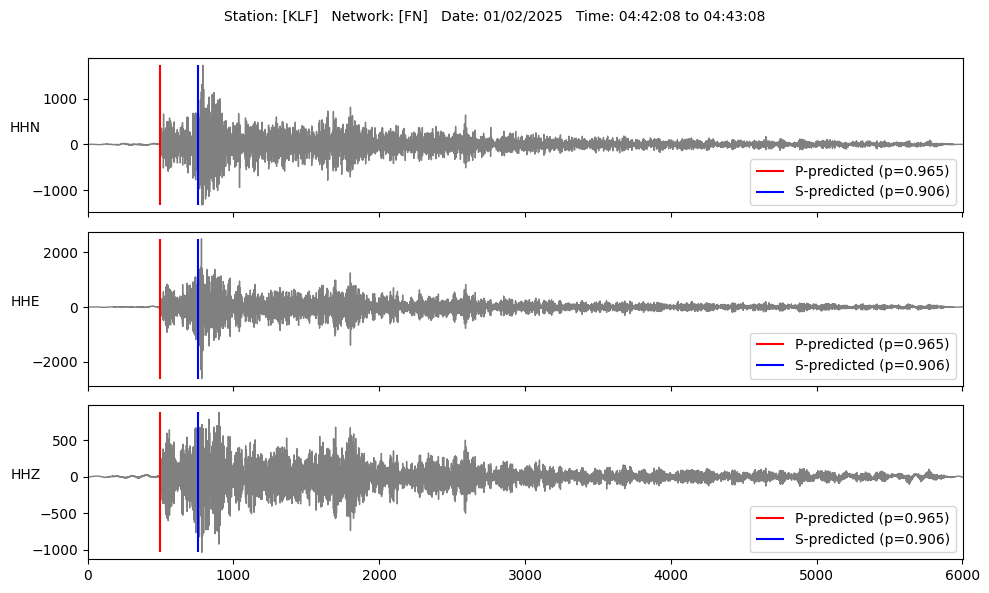

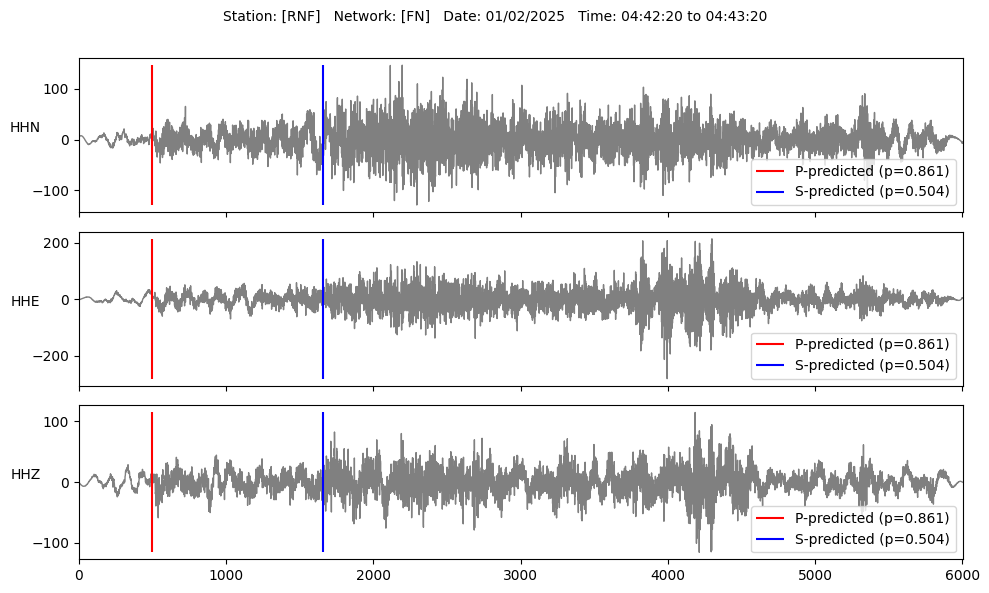

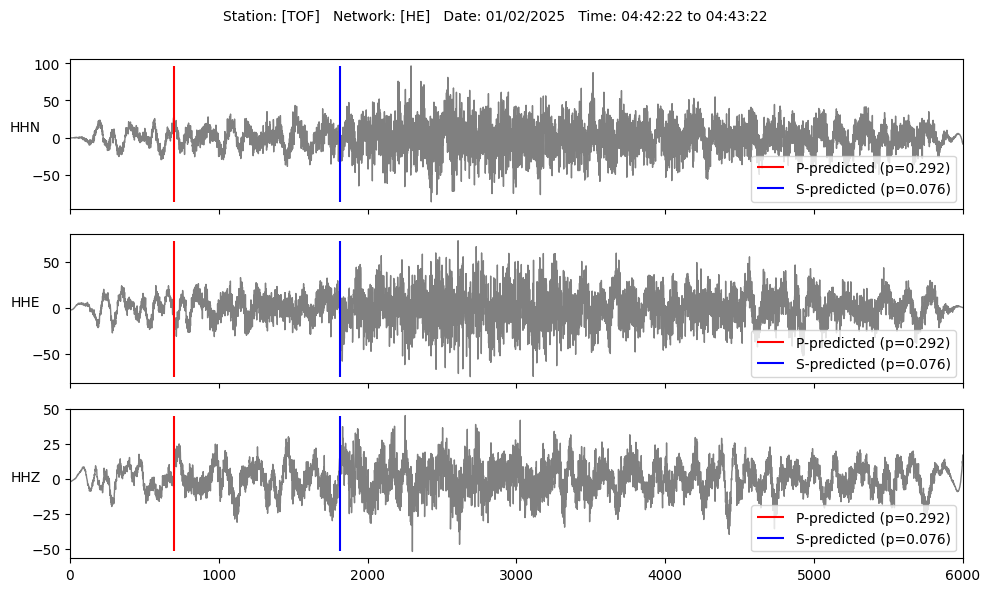

In [357]:
import re
from obspy import UTCDateTime

# Helper function for choosing the time of the trace
def add_time(dt, hours=0, minutes=0, seconds=0):
    return dt + hours * 3600 + minutes * 60 + seconds

# Path for .mseed data
data_dir = "../data/waveforms_earthquakes_nonoise/"
df = pd.read_csv(csv_output_path + csv_output_name)

# Extract information from filename to look for corresponding .mseed files
pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(pattern)

# Currently predictions are seemingly only for one of three channels
# This is a workaround for loading all three channels
channels = ["HHN", "HHE", "HHZ"]

# Plot a selected number of waveforms with predictions
for i in range(10):
    # Strings for assembling the filename
    station = matches["station"][i]
    network = matches["network"][i]
    start_dt = matches["start_dt"][i]
    end_dt = matches["end_dt"][i]

    # Construct the time window folder
    time_window_dir = os.path.join(data_dir, f"{start_dt}_{end_dt}/{station}")

    st = []

    for channel in channels:
        # Create filepath for each channel
        filename = f"{network}.{station}..{channel}__{start_dt}__{end_dt}.mseed"
        filepath = os.path.join(time_window_dir, filename)

        # Add each channel to the stream (if available)
        if os.path.exists(filepath):
            st += read(filepath)
        else:
            print(f"Warning: {filepath} not found")

    # Extract date and time information
    starttime = st[0].stats.starttime
    endtime = st[0].stats.endtime
    window_date = starttime.strftime("%m/%d/%Y")
    window_start = starttime.strftime("%H:%M:%S")
    window_end = endtime.strftime("%H:%M:%S")

    # Get sampling rate
    sampling_rate = st[0].stats.sampling_rate
    
    # If there is a predicted arrival time, set the picks by computing the waveform sample index
    refP = None
    refS = None
    if pd.notna(df["p_arrival_time"][i]):
        p_arr_time = UTCDateTime(df["p_arrival_time"][i])
        refP = int((p_arr_time - starttime) * sampling_rate)

    if pd.notna(df["s_arrival_time"][i]):
        s_arr_time = UTCDateTime(df["s_arrival_time"][i])
        refS = int((s_arr_time - starttime) * sampling_rate)
    
    # Set a manual threshold for the probability for plotting
    p_tr = 0.01
    if df["p_probability"][i] > p_tr and df["s_probability"][i] > p_tr:
        # === Plotting ===
        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
        # Event info to generate a plot title
        event_info = f"Station: [{station}]   Network: [{network}]   Date: {window_date}   Time: {window_start} to {window_end}\n"
        fig.suptitle(event_info,fontsize=10)

        for j, channel in enumerate(channels):
            # Copy the trace for processing
            tr_filt = st[j].copy()

            # Processing/filtering
            tr_filt.detrend("linear")
            tr_filt.detrend("demean")
            tr_filt.taper(max_percentage=0.05)
            tr_filt.filter('bandpass', freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)

            ax = axes[j]
            ax.plot(tr_filt.data, color="grey", linewidth=1)
            
            # Get the min and max y values
            y_min = tr_filt.data.min()
            y_max = tr_filt.data.max()
            
            # Plot vertical lines for predicted p- and s-wave arrivals
            if refP is not None:
                #ax.vlines(refP, y_min, y_max, color='r', linewidth=1.5, label=f'P-predicted (p={df["p_probability"][i]}), at {p_arr_time.strftime("%H:%M:%S")}')
                ax.vlines(refP, y_min, y_max, color='r', linewidth=1.5, label=f'P-predicted (p={df["p_probability"][i]})')
            if refS is not None:
                #ax.vlines(refS, y_min, y_max, color='b', linewidth=1.5, label=f'S-predicted (p={df["s_probability"][i]}), at {s_arr_time.strftime("%H:%M:%S")}')
                ax.vlines(refS, y_min, y_max, color='b', linewidth=1.5, label=f'S-predicted (p={df["s_probability"][i]})')
            # Set x limit
            ax.set_xlim(0, len(tr_filt.data))
            ax.set_ylabel(channel, rotation="horizontal")
            if refP is not None or refS is not None:
                ax.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

### Load quake-ML files with true picks

In [348]:
from obspy import read_events
import geopandas as gpd
from shapely.geometry import Point

qml_dir = Path("../data/qml_files")

paths = {
    "earthquakes": qml_dir / "earthquakes2025.qkml",
    "explosions": qml_dir / "explosions2025.qkml",
    "probable_explosions": qml_dir / "probable_explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml
probable_explosions: 1455 events loaded from probable_explosions2025.qkml


### Look at .qml event information

In [358]:
# Earthquake events catalog
eq_cat = catalogs["earthquakes"]
print(eq_cat)

# Inspect a single event by index
i = 0
event = eq_cat[i]
print(f"\nSingle event (index = {i}):")
print(event)
print("origins:", len(event.origins))          # number of location solutions
print("magnitudes:", len(event.magnitudes))    # number of magnitude estimates
print("picks:", len(event.picks))              # total phase picks across stations
print("comments:", event.comments)

for pick in event.picks:
    print(pick)

328 Event(s) in Catalog:
2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML
2025-01-02T04:42:09.800000Z | +67.059,  +24.110 | 0.2  ML
...
2025-12-28T22:31:37.900000Z | +65.044,  +27.374 | 1.1  ML
2025-12-30T11:43:17.500000Z | +61.567,  +24.258 | 1.1  ML
To see all events call 'print(CatalogObject.__str__(print_all=True))'

Single event (index = 0):
Event:	2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML

	            resource_id: ResourceIdentifier(id="smi:fi.isuh/event/1490639")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:fi.isuh/origin/1490639")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:fi.isuh/magnitude/1490639")
	                   ---------
	     event_descriptions: 1 Elements
	               comments: 3 Elements
	                  picks: 18 Elements
	             amplitudes: 3 Elements
	       focal_mechanisms: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements
origins: 1


In [359]:
# Get information about the catalogue: 
# Earliest and latest picks and
# dictionary of networks and stations (with waveforms)
pick_times = []
station_dict_cat = {}

for event in eq_cat:
    for pick in event.picks:
        if pick.waveform_id is None:
            continue
        
        # Get network and station from waveform id (if available)
        network = pick.waveform_id.network_code
        station = pick.waveform_id.station_code

        if network and station:
            if network not in station_dict_cat:
                station_dict_cat[network] = set()
            station_dict_cat[network].add(station)

        # Append pick time to the list of pick times
        pick_times.append(pick.time)

print(f"Earliest pick: {min(pick_times)}")
print(f"Latest pick: {max(pick_times)}")

for network in sorted(station_dict_cat):
    print(f"{network}: {sorted(station_dict_cat[network])}")

# Create a dictionary only for networks/stations contained in predictions
network_list = ["HE", "FN","UP"]
station_dict = dict.fromkeys(["HE", "FN","UP"])
for ntwk in network_list:
    station_dict[ntwk] = df[matches["network"] == ntwk]["station"].unique()

Earliest pick: 2025-01-01T09:22:01.256470Z
Latest pick: 2025-12-30T11:44:33.362750Z
EE: ['ARBE', 'EE04', 'EE06', 'MTSE', 'NOPE', 'PISE', 'PLDE', 'SRGE', 'TOSE', 'VSU']
FN: ['KLF', 'KMNF', 'MSF', 'OLKF', 'OUL', 'RAJF', 'RANF', 'RNF', 'SGF']
GE: ['SLIT']
HE: ['ALAJF', 'ECKF', 'FIA0', 'FIA1', 'HEF', 'HEL1', 'HEL5', 'JOF', 'KAF', 'KEF', 'KEV', 'KIF', 'KJNF', 'KOFF', 'KORF', 'KPF', 'KU1', 'KU2', 'KU6', 'KUNI', 'KY02', 'KY17', 'LAUT', 'LEPP', 'LOVF', 'MEF', 'NIF', 'NUR', 'OBF0', 'OBF3', 'OBF8', 'OUF', 'PVF', 'RAF', 'RMF', 'RSUO', 'RUF', 'SUF', 'TOF', 'TRE03', 'TVF', 'VAF', 'VJF', 'VRF', 'VUOS']
NO: ['ARA0', 'BEA1', 'JETT']
NS: ['FAUS', 'GILDE', 'HAMF', 'KONS', 'KTK1', 'LEIR', 'LENS', 'LOF', 'LOSSI', 'NSS', 'ROROS', 'STEI', 'STOK', 'TRO', 'VADS', 'VAGH', 'VBYGD']
UP: ['AAL', 'ARNU', 'BURU', 'ERTU', 'GOTU', 'HEMU', 'HUSU', 'KALU', 'LANU', 'NRTU', 'PAJU']


### Compile true p- and s-picks into dataframe

In [360]:
# Create a dictionary only for networks/stations contained in predictions
network_list = df["network"].unique()
station_dict = dict.fromkeys(network_list)
for ntwk in network_list:
    station_dict[ntwk] = df[matches["network"] == ntwk]["station"].unique()
station_dict

{'HE': array(['HEF', 'TOF', 'OBF8', 'OBF0', 'OUF', 'VAF', 'OBF3', 'ALAJF', 'SUF',
        'NIF', 'KIF', 'KPF', 'RAF', 'KU6', 'VRF', 'RMF', 'VJF', 'FIA0',
        'FIA1', 'VUOS', 'KUNI', 'LAUT', 'HEL1', 'RUF', 'MEF', 'KAF', 'KEF',
        'TVF', 'NUR', 'HEL5', 'KEV', 'JOF', 'RSUO'], dtype=object),
 'FN': array(['KLF', 'SGF', 'RNF', 'RANF', 'OUL', 'MSF', 'OLKF', 'RAJF', 'KMNF'],
       dtype=object),
 'UP': array(['AAL'], dtype=object)}

In [363]:
# Extract picks from earthquake catalogue
p_alias = {"P", "PG", "PB", "PN"}
s_alias = {"S", "SG", "SB", "SN"}

times = []
networks = []
stations = []
phases = []
event_ids = []

for event in eq_cat:
    event_id = event.resource_id

    # Get pick information per event
    for pick in event.picks:
        pick_time = pick.time
        # Only get pick information if a waveform is available
        if pick.waveform_id is None:
            continue
        pick_network = pick.waveform_id.network_code
        pick_station = pick.waveform_id.station_code
        pick_phase_hint = pick.phase_hint
        
        # Ensure that picks belong to the same list of networks and stations as predictions
        if pick_network in station_dict.keys() and pick_station in station_dict[pick_network]:
            if pick_phase_hint:
                ph = (pick_phase_hint or "").upper().strip()
                if ph in p_alias:
                    pick_phase = "P"
                elif ph in s_alias:
                    pick_phase = "S"
                else:
                    continue
            
            # Append pick information to lists
            times.append(pick_time.datetime)
            networks.append(pick_network)
            stations.append(pick_station)
            phases.append(pick_phase)
            event_ids.append(event_id)

# Compile data to dataframe
df_true = pd.DataFrame({"event_id": event_ids, "true_arrival_time": times, "network": networks, "station": stations, "phase": phases})

# Print number of respective phase types
print(df_true["phase"].value_counts())

S    2433
P    1578
Name: phase, dtype: int64


### Match and merge dataframes for predictions and actual picks

In [405]:
# Probability threshold
p_threshold = 0.05

# Split predicted p-arrivals and s-arrivals into dataframes
df_pred = df.sort_values("start_dt")
df_pred_p = df_pred[["network", "station", "p_arrival_time", "p_probability", "start_dt", "end_dt"]].rename(columns={"p_arrival_time": "pred_arrival_time", "p_probability": "probability"})
df_pred_s = df_pred[["network", "station", "s_arrival_time", "s_probability", "start_dt", "end_dt"]].rename(columns={"s_arrival_time": "pred_arrival_time", "s_probability": "probability"})

# Add a phase column
df_pred_p["phase"] = "P"
df_pred_s["phase"] = "S"

# Concatenate into one longer dataframe
df_pred_long = pd.concat([df_pred_p, df_pred_s], ignore_index=True)
df_pred_long = df_pred_long.dropna()
df_pred_long = df_pred_long[df_pred_long["probability"] > p_threshold]

# Convert to standard datetime
df_pred_long["pred_arrival_time"] = pd.to_datetime(df_pred_long["pred_arrival_time"])
df_true["true_arrival_time"] = pd.to_datetime(df_true["true_arrival_time"])

# Keep only P and S-picks from ground truth
df_true = df_true[df_true["phase"].isin(["P", "S"])]

# Sort by datetime for both
df_pred_long = df_pred_long.sort_values("pred_arrival_time")
df_true = df_true.sort_values("true_arrival_time")

In [409]:
# How much time between predictions and true picks to accept
delta = pd.Timedelta("2s")

# Dataframe merging predictions on ground truth -> TP and FP
preds_on_picks = pd.merge_asof(
    df_pred_long,
    df_true,
    left_on="pred_arrival_time",
    right_on="true_arrival_time",
    by=["network", "station", "phase"],
    tolerance=delta,
    direction="nearest"
)

# Dataframe merging ground truth on predictions -> TP and FN
picks_on_preds = pd.merge_asof(
    df_true,
    df_pred_long,
    left_on="true_arrival_time",
    right_on="pred_arrival_time",
    by=["network", "station", "phase"],
    tolerance=delta,
    direction="nearest"
)

### Early metrics

In [410]:
# Count number of total (true) picks and predictions
num_picks = len(picks_on_preds)
num_preds = len(preds_on_picks)

# Compute TP, FP and FN
TP = picks_on_preds["probability"].notna().sum()
FP = num_preds - TP
FN = num_picks - TP

# Recall = fraction of true picks detected
recall = TP / (TP + FN)

# Precision = fraction of correct predictions
precision = TP / (TP + FP)

# F1 score
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"True Positives:\t\t{TP}\nFalse Positives:\t{FP}\nFalse Negatives:\t{FN}")
print(f"Total predictions:\t{num_preds}")
print(f"Total picks:\t\t{num_picks}")
print(f"Recall:\t\t\t{recall}\nPrecision:\t\t{precision}\nF1 Score:\t\t{f1_score}")

True Positives:		2882
False Positives:	840
False Negatives:	1129
Total predictions:	3722
Total picks:		4011
Recall:			0.7185240588381949
Precision:		0.7743148844707146
F1 Score:		0.7453769559032717


In [411]:
# Filter p and s picks to monitor accuracy difference between the two models
p_picks_on_preds = picks_on_preds[picks_on_preds["phase"] == "P"]
s_picks_on_preds = picks_on_preds[picks_on_preds["phase"] == "S"]
p_preds_on_picks = preds_on_picks[preds_on_picks["phase"] == "P"]
s_preds_on_picks = preds_on_picks[preds_on_picks["phase"] == "S"]

# True positives (Prediction and event match within the given timedelta)
TP_p = p_picks_on_preds["probability"].notna().sum()
TP_s = s_picks_on_preds["probability"].notna().sum()

# "False positives" (Predictions without corresponding event)
FP_p = len(p_preds_on_picks) - TP_p
FP_s = len(s_preds_on_picks) - TP_s

# # False negatives (No prediction for true pick found)
FN_p = len(p_picks_on_preds) - TP_p
FN_s = len(s_picks_on_preds) - TP_s

# Recall
recall_p = TP_p / (TP_p + FN_p)
recall_s = TP_s / (TP_s + FN_s)

# Precision
precision_p = TP_p / (TP_p + FP_p)
precision_s = TP_s / (TP_s + FP_s)

# F1 score
f1_score_p = 2 * (precision_p * recall_p) / (precision_p + recall_p)
f1_score_s = 2 * (precision_s * recall_s) / (precision_s + recall_s)

print(f"=========== Metrics for p-picks ===========")
print(f"True Positives:\t\t{TP_p}\nFalse Positives:\t{FP_p}\nFalse Negatives:\t{FN_p}")
print(f"Total predictions:\t{len(p_preds_on_picks)}")
print(f"Total picks:\t\t{len(p_picks_on_preds)}")
print(f"Recall:\t\t\t{recall_p}\nPrecision:\t\t{precision_p}\nF1 Score:\t\t{f1_score_p}")
print(f"\n=========== Metrics for s-picks ===========")
print(f"True Positives:\t\t{TP_s}\nFalse Positives:\t{FP_s}\nFalse Negatives:\t{FN_s}")
print(f"Total predictions:\t{len(s_preds_on_picks)}")
print(f"Total picks:\t\t{len(s_picks_on_preds)}")
print(f"Recall:\t\t\t{recall_s}\nPrecision:\t\t{precision_s}\nF1 Score:\t\t{f1_score_s}")

=========== Metrics for p-picks ===========
True Positives:		1513
False Positives:	652
False Negatives:	65
Total predictions:	2165
Total picks:		1578
Recall:			0.958808618504436
Precision:		0.6988452655889146
F1 Score:		0.8084424258616084

=========== Metrics for s-picks ===========
True Positives:		1369
False Positives:	188
False Negatives:	1064
Total predictions:	1557
Total picks:		2433
Recall:			0.5626798191533087
Precision:		0.8792549775208734
F1 Score:		0.6862155388471178


### Plot predictions versus true picks (only for correct predictions within e.g. 2s)

../data/waveforms_earthquakes_nonoise/20250101T092157Z_20250101T092257Z/HEF


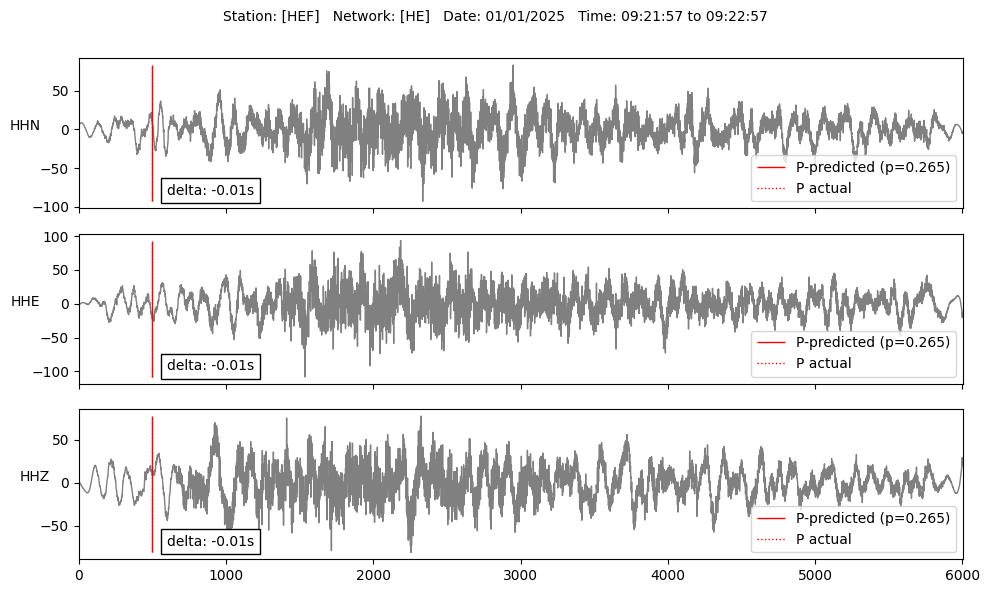

../data/waveforms_earthquakes_nonoise/20250101T092202Z_20250101T092302Z/KLF


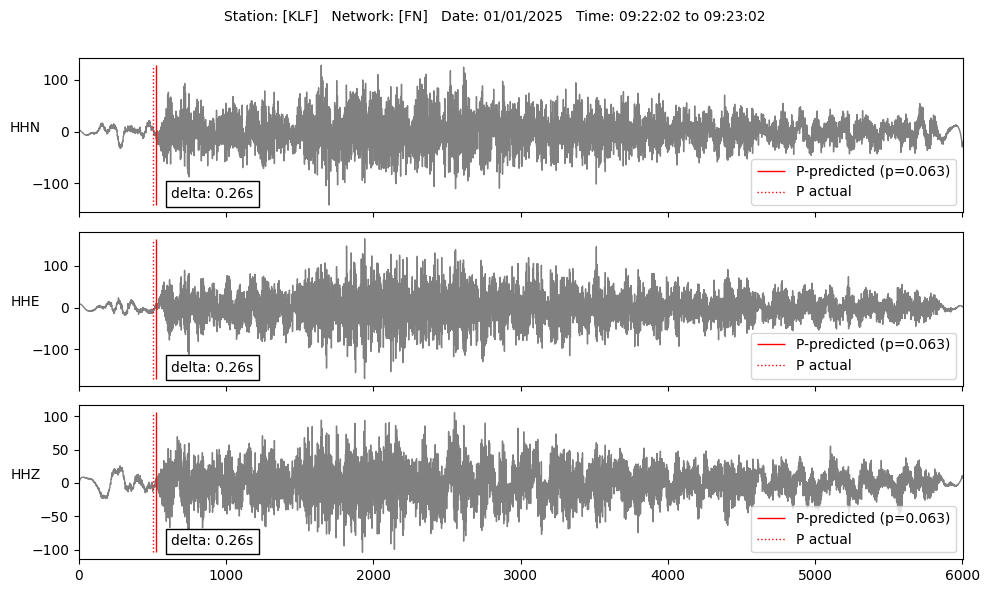

../data/waveforms_earthquakes_nonoise/20250101T092202Z_20250101T092302Z/KLF


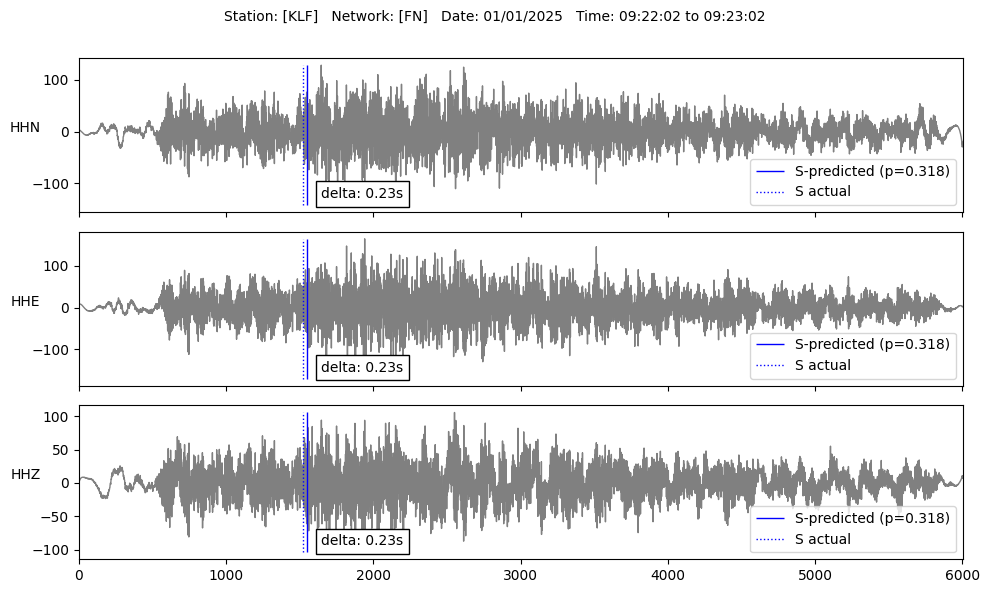

../data/waveforms_earthquakes_nonoise/20250101T092218Z_20250101T092318Z/RNF


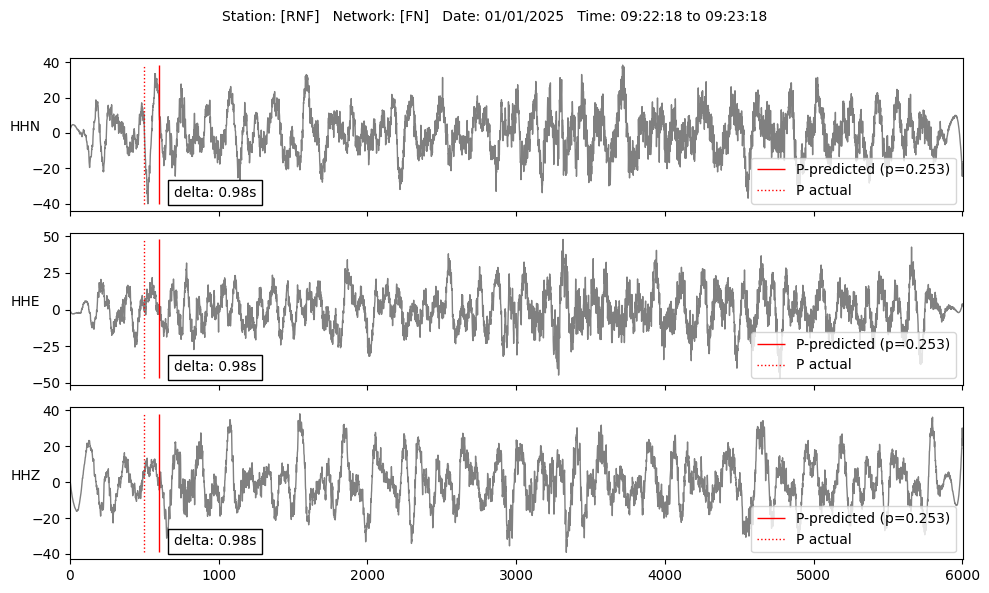

../data/waveforms_earthquakes_nonoise/20250102T044208Z_20250102T044308Z/KLF


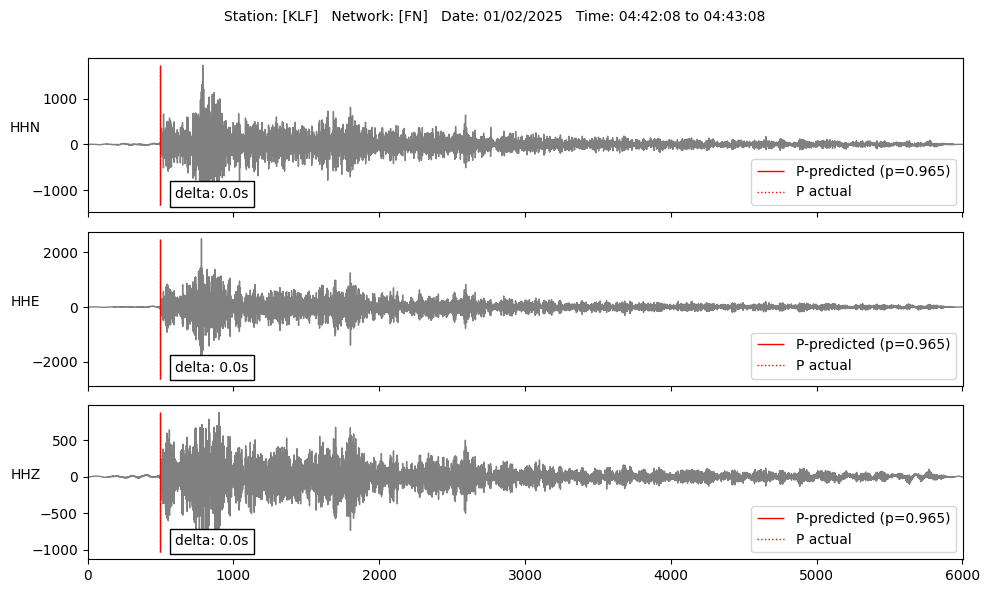

../data/waveforms_earthquakes_nonoise/20250102T044208Z_20250102T044308Z/KLF


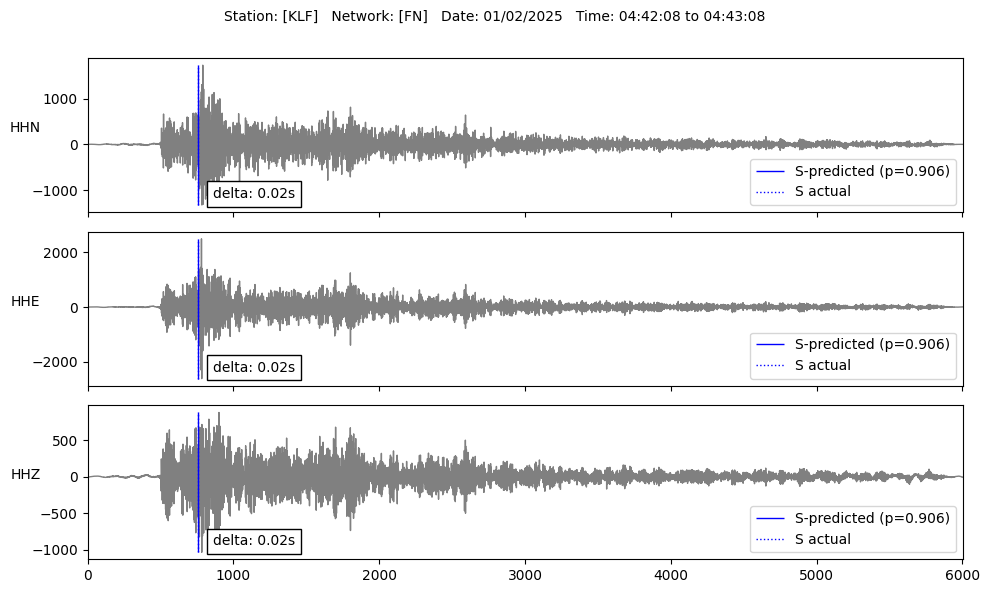

In [419]:
# Path for .mseed data
data_dir = "../data/waveforms_earthquakes_nonoise/"
df = pd.read_csv(csv_output_path + csv_output_name)

# Currently predictions are seemingly only for one of three channels
# This is a workaround for loading all three channels
channels = ["HHN", "HHE", "HHZ"]

for i in range(8):
    if pd.notna(preds_on_picks["event_id"][i]):
        # Strings for assembling the filename
        station = preds_on_picks["station"][i]
        network = preds_on_picks["network"][i]
        start_dt = UTCDateTime(preds_on_picks["start_dt"][i]).strftime("%Y%m%dT%H%M%SZ")
        end_dt = UTCDateTime(preds_on_picks["end_dt"][i]).strftime("%Y%m%dT%H%M%SZ")

        # Construct the time window folder
        time_window_dir = os.path.join(data_dir, f"{start_dt}_{end_dt}/{station}")
        print(time_window_dir)
        st = []

        for channel in channels:
            # Create filepath for each channel
            filename = f"{network}.{station}..{channel}__{start_dt}__{end_dt}.mseed"
            filepath = os.path.join(time_window_dir, filename)

            # Add each channel to the stream (if available)
            if os.path.exists(filepath):
                st += read(filepath)
            else:
                print(f"Warning: {filepath} not found")

        # Extract date and time information
        starttime = st[0].stats.starttime
        endtime = st[0].stats.endtime
        sampling_rate = st[0].stats.sampling_rate
        window_date = starttime.strftime("%m/%d/%Y")
        window_start = starttime.strftime("%H:%M:%S")
        window_end = endtime.strftime("%H:%M:%S")
        
        # If there is a predicted arrival time, determine the picks by computing the waveform sample index
        predP = None
        predS = None
        refP = None
        refS = None
    
        # Set the arrival times of the true picks
        if pd.notna(preds_on_picks["pred_arrival_time"][i]):
            if preds_on_picks["phase"][i] == "P":
                p_arr_time_pred = UTCDateTime(preds_on_picks["pred_arrival_time"][i])
                p_arr_time_true = UTCDateTime(preds_on_picks["true_arrival_time"][i])
                predP = int((p_arr_time_pred - starttime) * sampling_rate)
                refP = int((p_arr_time_true - starttime) * sampling_rate)

            elif preds_on_picks["phase"][i] == "S":
                s_arr_time_pred = UTCDateTime(preds_on_picks["pred_arrival_time"][i])
                s_arr_time_true = UTCDateTime(preds_on_picks["true_arrival_time"][i])
                predS = int((s_arr_time_pred - starttime) * sampling_rate)
                refS = int((s_arr_time_true - starttime) * sampling_rate)
            
        # Set a manual threshold for the probability for plotting
        p_threshold = 0.05
        if preds_on_picks["probability"][i] > p_threshold:
            # === Plotting ===
            fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
            # Event info to generate a plot title
            event_info = f"Station: [{station}]   Network: [{network}]   Date: {window_date}   Time: {window_start} to {window_end}\n"
            fig.suptitle(event_info,fontsize=10)

            for j, channel in enumerate(channels):
                # Get sampling rate
                sampling_rate = st[j].stats.sampling_rate

                # Copy the trace for processing
                tr_filt = st[j].copy()

                # Processing/filtering
                tr_filt.detrend("linear")
                tr_filt.detrend("demean")
                tr_filt.taper(max_percentage=0.05)
                tr_filt.filter('bandpass', freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)

                ax = axes[j]
                ax.plot(tr_filt.data, color="grey", linewidth=1)
                
                # Get the min and max y values
                y_min = tr_filt.data.min()
                y_max = tr_filt.data.max()
                text_pos = y_min + (y_max - y_min)/20
                
                # Plot vertical lines for predicted p- and s-wave arrivals
                if predP is not None:
                    ax.vlines(predP, y_min, y_max, color='r', linewidth=1, label=f'P-predicted (p={preds_on_picks["probability"][i]})')
                    ax.vlines(refP, y_min, y_max, color='r', linewidth=1, linestyles='dotted', label=f'P actual')
                    ax.text(x=predP+100, y=text_pos, s=f"delta: {(predP-refP)/sampling_rate}s", bbox=dict(facecolor='w', alpha=1))
                if predS is not None:
                    ax.vlines(predS, y_min, y_max, color='b', linewidth=1, label=f'S-predicted (p={preds_on_picks["probability"][i]})')
                    ax.vlines(refS, y_min, y_max, color='b', linewidth=1, linestyles='dotted', label=f'S actual')
                    ax.text(x=predS+100, y=text_pos, s=f"delta: {(predS-refS)/sampling_rate}s", bbox=dict(facecolor='w', alpha=1))
                # Set x limit
                ax.set_xlim(0, len(tr_filt.data))
                ax.set_ylabel(channel, rotation="horizontal")
                ax.legend(loc='lower right')
            plt.tight_layout()
            plt.show()

## Plot some "False Positives" as they may be earthquakes missed by human pickers
#### WIP: currently used waveforms always contain picks!

In [ ]:
# Look for some "False Positives", time delta of 60s to assure that true pick is more than 60s apart from prediction
# Effectively leaves only predictions outside of the actual waveform
preds_on_picks_anyphase = pd.merge_asof(
    df_pred_long.sort_values("pred_arrival_time"),
    df_true.sort_values("true_arrival_time"),
    left_on="pred_arrival_time",
    right_on="true_arrival_time",
    by=["network","station"],
    tolerance=pd.Timedelta("60s"),
    direction="nearest"
)

false_positives = preds_on_picks_anyphase[
    preds_on_picks_anyphase["true_arrival_time"].isna()
]
false_positives = false_positives.rename(columns={"phase_x": "phase"})

In [ ]:
false_positives

,network,station,pred_arrival_time,probability,start_dt,end_dt,phase,event_id,true_arrival_time,phase_y
554,HE,KU6,2025-02-15 21:02:22.930,0.066,2025-02-15 21:01:12,2025-02-15 21:02:12,P,NaN,NaT,NaN
2768,HE,OBF3,2025-10-03 01:00:35.692,0.087,2025-10-03 00:59:25,2025-10-03 01:00:25,P,NaN,NaT,NaN
2913,HE,OBF0,2025-10-16 14:27:28.996,0.112,2025-10-16 14:26:18,2025-10-16 14:27:18,P,NaN,NaT,NaN
3095,HE,HEF,2025-10-31 14:36:55.470,0.053,2025-10-31 14:35:45,2025-10-31 14:36:45,P,NaN,NaT,NaN
3216,HE,HEF,2025-11-17 23:30:04.550,0.055,2025-11-17 23:28:53,2025-11-17 23:29:53,P,NaN,NaT,NaN
3409,HE,KEV,2025-12-09 14:09:51.020,0.060,2025-12-09 14:08:40,2025-12-09 14:09:40,P,NaN,NaT,NaN
3645,HE,OBF3,2025-12-25 16:39:41.904,0.073,2025-12-25 16:38:31,2025-12-25 16:39:31,P,NaN,NaT,NaN
3646,HE,KPF,2025-12-25 16:39:42.864,0.070,2025-12-25 16:38:31,2025-12-25 16:39:31,P,NaN,NaT,NaN
3675,FN,RAJF,2025-12-27 01:40:31.790,0.073,2025-12-27 01:39:21,2025-12-27 01:40:21,P,NaN,NaT,NaN


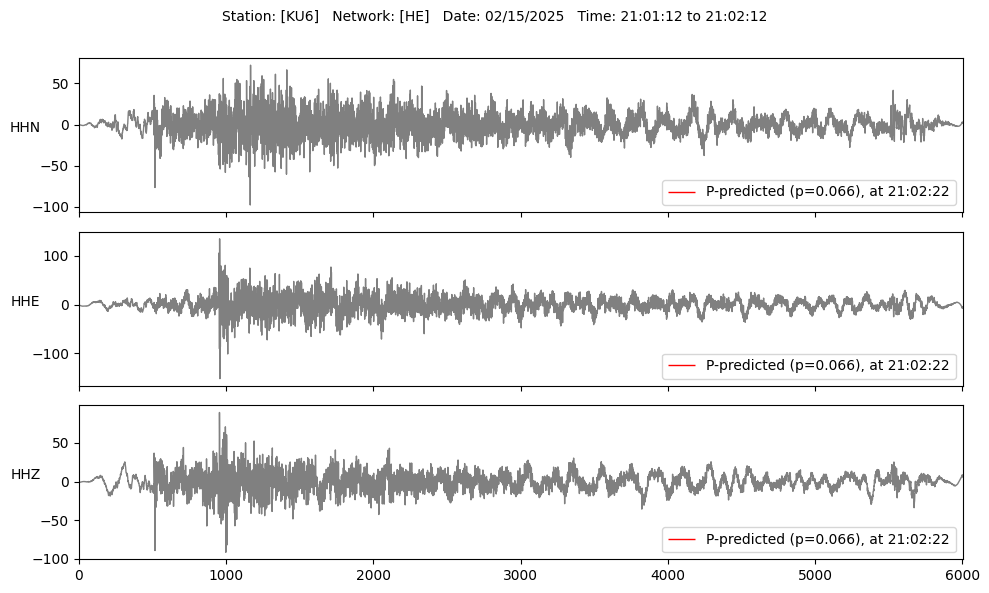

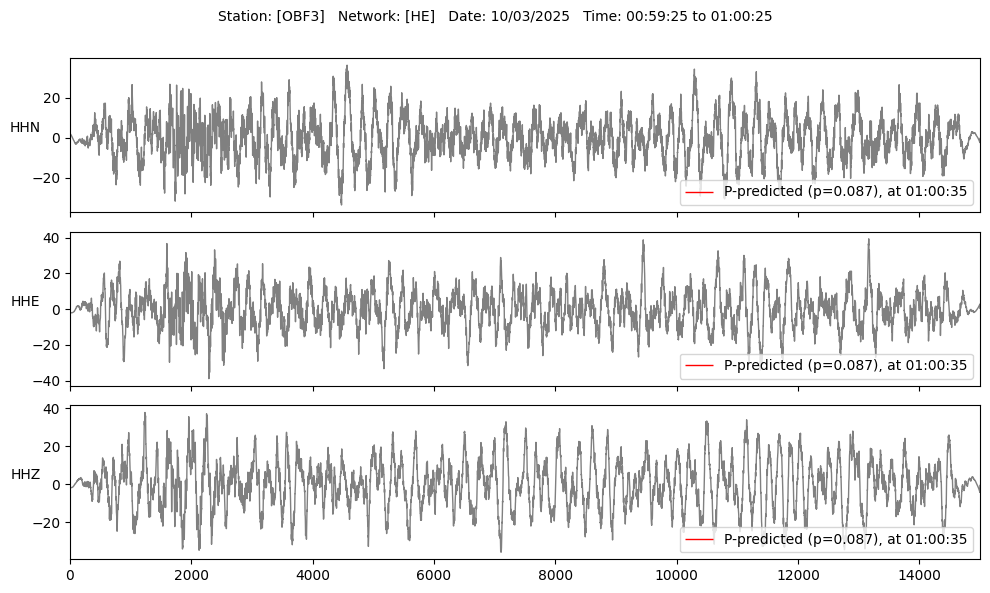

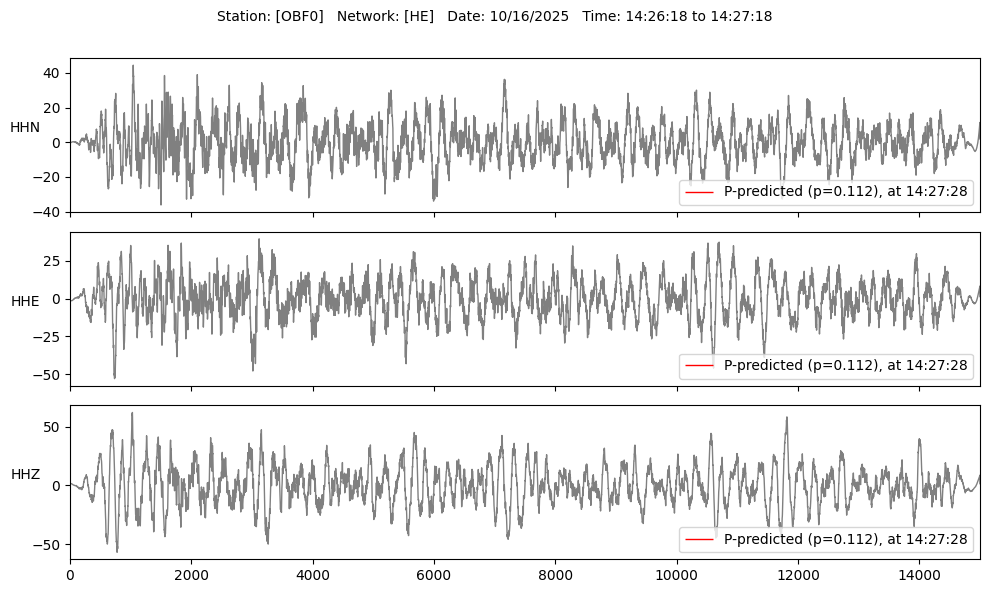

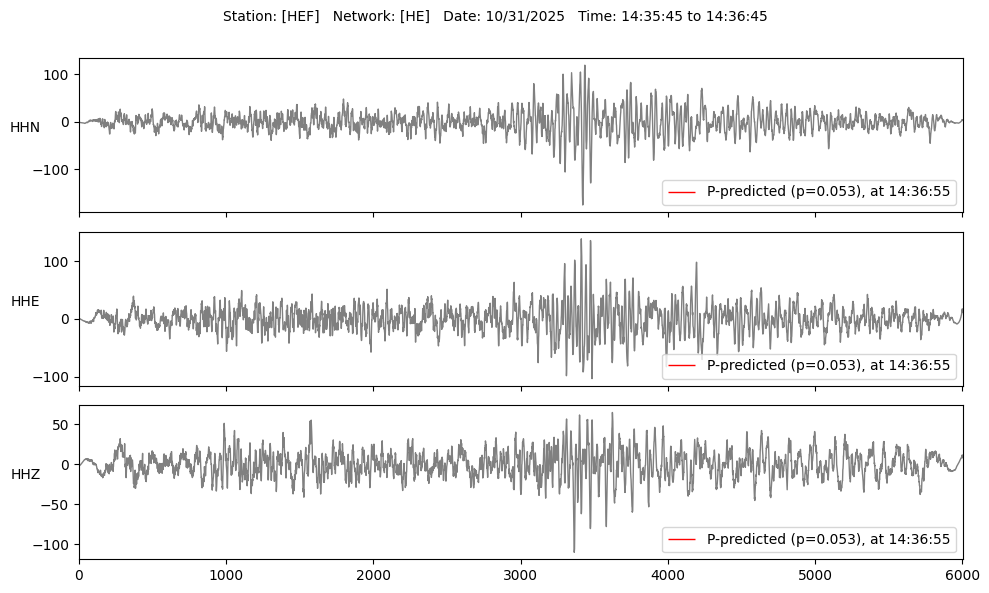

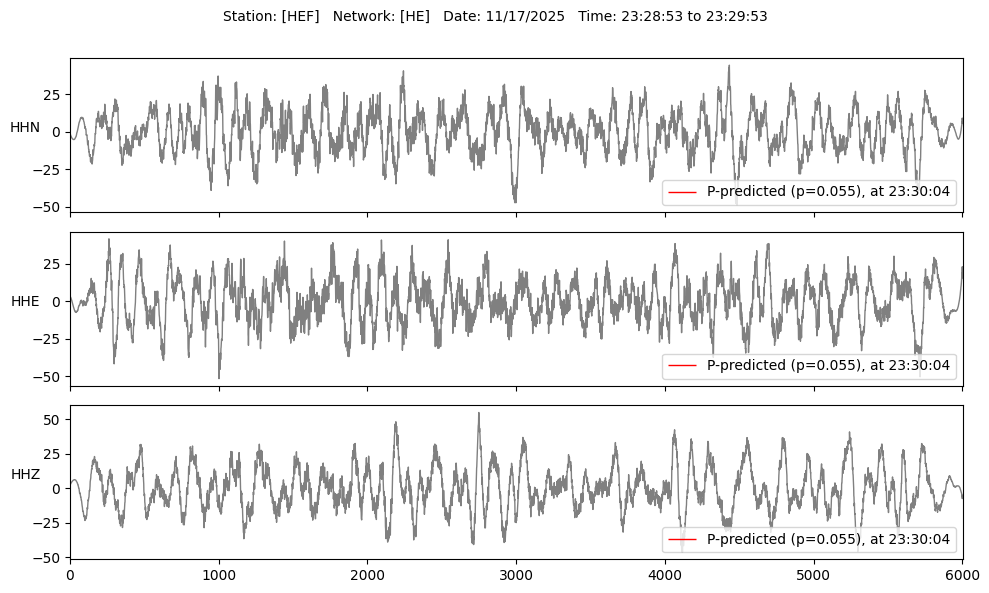

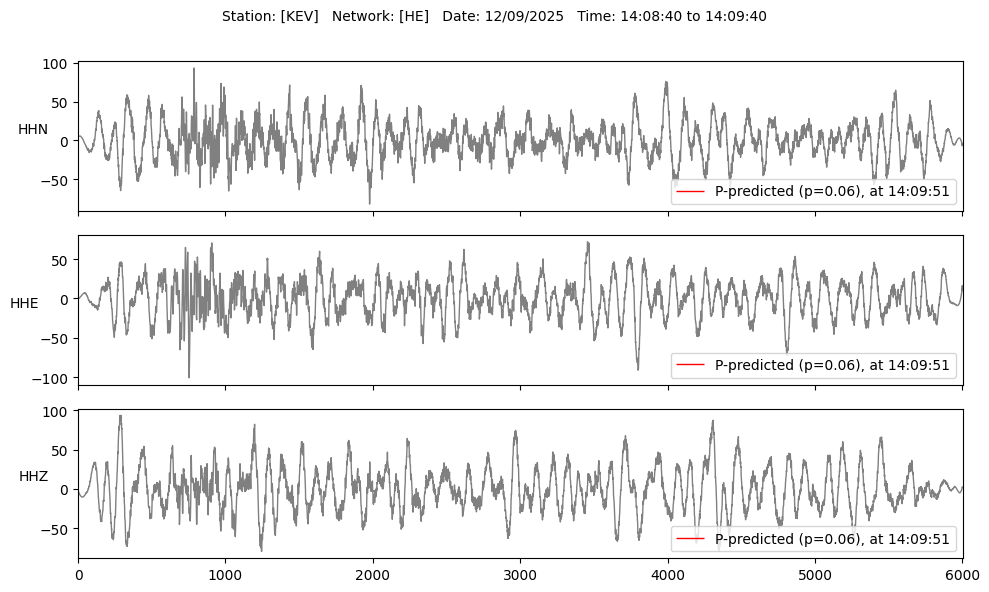

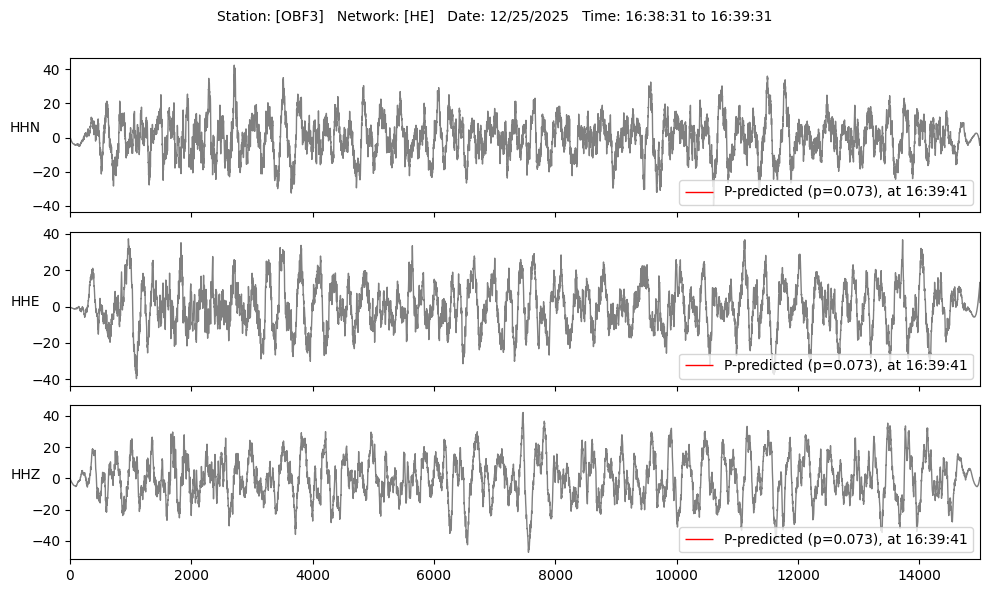

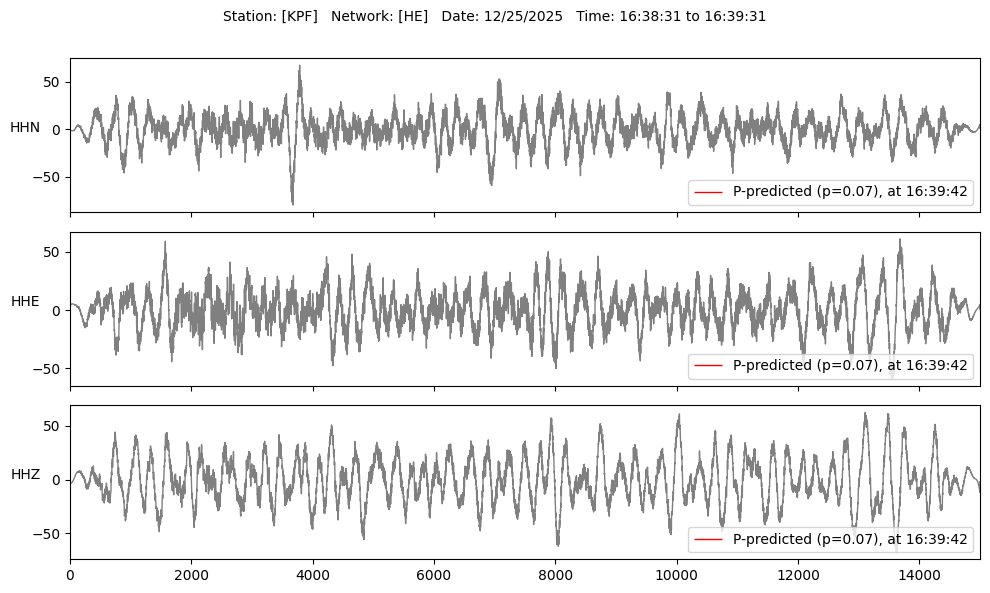

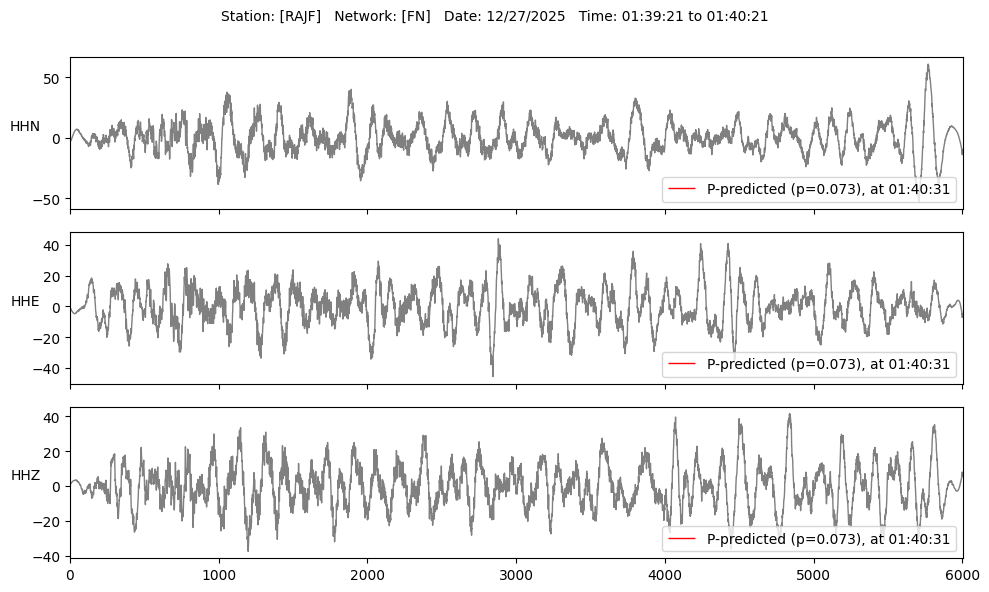

In [452]:
# Loop through a number of examples
for _, row in false_positives.head(10).iterrows():
    # Strings for assembling the filename, strip spaces just in case
    station = row["station"]
    network = row["network"]
    start_dt = UTCDateTime(row["start_dt"]).strftime("%Y%m%dT%H%M%SZ")
    end_dt = UTCDateTime(row["end_dt"]).strftime("%Y%m%dT%H%M%SZ")

    # Construct the time window folder
    time_window_dir = os.path.join(data_dir, f"{start_dt}_{end_dt}/{station}")
    st = []

    for channel in channels:
        # Create filepath for each channel
        filename = f"{network}.{station}..{channel}__{start_dt}__{end_dt}.mseed"
        filepath = os.path.join(time_window_dir, filename)

        # Add each channel to the stream (if available)
        if os.path.exists(filepath):
            st += read(filepath)
        else:
            print(f"Warning: {filepath} not found")

    # Extract date and time information
    starttime = st[0].stats.starttime
    endtime = st[0].stats.endtime
    sampling_rate = st[0].stats.sampling_rate
    window_date = starttime.strftime("%m/%d/%Y")
    window_start = starttime.strftime("%H:%M:%S")
    window_end = endtime.strftime("%H:%M:%S")
    
    # If there is a predicted arrival time, determine the picks by computing the waveform sample index
    predP = None
    predS = None

    if pd.notna(row["pred_arrival_time"]):
        if row["phase"] == "P":
            predP = int((UTCDateTime(row["pred_arrival_time"]) - starttime) * sampling_rate)
        elif row["phase"] == "S":
            predS = int((UTCDateTime(row["pred_arrival_time"]) - starttime) * sampling_rate)
    
    # === Plotting ===
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
    # Event info to generate a plot title
    event_info = f"Station: [{station}]   Network: [{network}]   Date: {window_date}   Time: {window_start} to {window_end}\n"
    fig.suptitle(event_info,fontsize=10)

    for j, channel in enumerate(channels):
        # Get sampling rate
        sampling_rate = st[j].stats.sampling_rate

        # Copy the trace for processing
        tr_filt = st[j].copy()

        # Processing/filtering
        tr_filt.detrend("linear")
        tr_filt.detrend("demean")
        tr_filt.taper(max_percentage=0.05)
        tr_filt.filter('bandpass', freqmin=1.0, freqmax=45.0, corners=2, zerophase=True)

        ax = axes[j]
        ax.plot(tr_filt.data, color="grey", linewidth=1)
        
        # Get the min and max y values
        y_min = tr_filt.data.min()
        y_max = tr_filt.data.max()
        text_pos = y_min + (y_max - y_min)/20
        
        # Plot vertical lines for predicted p- and s-wave arrivals
        if predP is not None:
            ax.vlines(predP, y_min, y_max, color='r', linewidth=1, label=f'P-predicted (p={row["probability"]}), at {UTCDateTime(row["pred_arrival_time"]).strftime("%H:%M:%S")}')
        if predS is not None:
            ax.vlines(predS, y_min, y_max, color='b', linewidth=1, label=f'S-predicted (p={row["probability"]}), at {UTCDateTime(row["pred_arrival_time"]).strftime("%H:%M:%S")}')
        # Set x limit
        ax.set_xlim(0, len(tr_filt.data))
        ax.set_ylabel(channel, rotation="horizontal")
        ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()